In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the dataset
df = pd.read_csv("/content/youtube_dataset.csv")

df.head()

,Video_title,Channel_name,Owner_name,Category,Video_language,Country,Views_in_millions,Likes_in_thousands,Dislikes_in_thousands,Comment_in_thousands,Duration_in_minutes,Upload_date
0,I Tried Every Kind of Amusement Park,Addie Bowley,Addie Bowley,Entertainment,English,USA,0.732,166.000,0.100,1.540,25.0,8/23/2025
1,I Tested the Worlds Most Extreme Airbnbs,Addie Bowley,Addie Bowley,Lifestyle,English,USA,1.400,28.000,0.210,1.700,23.0,4/26/2025
2,Best Podcasts For Learning English,Aleena Rais Live,Aleena Rais,Education,English,India,0.040,2.000,0.006,0.087,20.0,8/13/2025
3,The Best Performance Mod (maintenance),Zip Tie Tuning,Alex,Techonology,English,Canada,0.320,27.000,0.087,1.250,15.0,6/28/2025
4,Learn Java in 14 Minutes (seriously),Alex Lee,Alex Lee,Education,English,USA,5.210,5.215,21.690,6.248,24.0,4/18/2019


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Video_title            100 non-null    object 
 1   Channel_name           100 non-null    object 
 2   Owner_name             100 non-null    object 
 3   Category               100 non-null    object 
 4   Video_language         100 non-null    object 
 5   Country                100 non-null    object 
 6   Views_in_millions      100 non-null    float64
 7   Likes_in_thousands     100 non-null    float64
 8   Dislikes_in_thousands  100 non-null    float64
 9   Comment_in_thousands   100 non-null    float64
 10  Duration_in_minutes    100 non-null    float64
 11  Upload_date            100 non-null    object 
dtypes: float64(5), object(7)
memory usage: 9.5+ KB


In [3]:
df.columns

Index(['Video_title', 'Channel_name', 'Owner_name', 'Category',
       'Video_language', 'Country', 'Views_in_millions', 'Likes_in_thousands',
       'Dislikes_in_thousands', 'Comment_in_thousands', 'Duration_in_minutes',
       'Upload_date'],
      dtype='object')

In [4]:
# Count unique video titles
unique_videos = df['Video_title'].nunique()
print("Total Unique Videos:", unique_videos)


Total Unique Videos: 95


In [5]:
# Count unique channels
unique_channels = df['Channel_name'].nunique()

# Count unique owners
unique_owners = df['Owner_name'].nunique()

print("Unique Channels:", unique_channels)
print("Unique Owners:", unique_owners)


Unique Channels: 53
Unique Owners: 51


In [6]:
# Count videos per category
category_distribution = df['Category'].value_counts()
print(category_distribution)

Category
Lifestyle        29
Entertainment    25
Education        20
Techonology      16
Gaming           10
Name: count, dtype: int64


In [7]:
# Count videos per language
language_count = df['Video_language'].value_counts()
print(language_count)


Video_language
English    77
Hindi      23
Name: count, dtype: int64


In [8]:
# Count videos per country
country_count = df['Country'].value_counts()
print(country_count)

Country
USA          47
India        30
Canada        8
UK            6
Korea         6
Japan         2
Australia     1
Name: count, dtype: int64


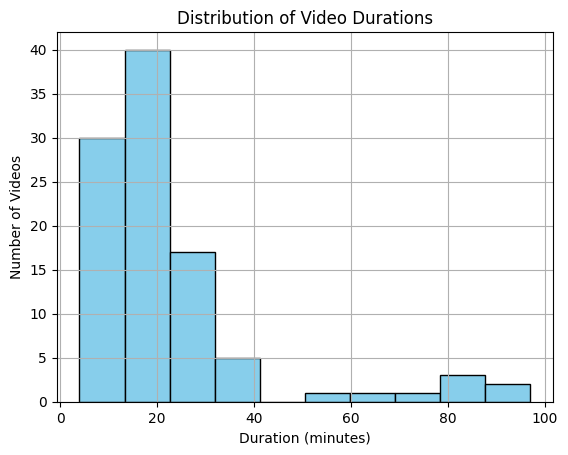

Most Common Duration: 15.0


In [9]:
# Plot histogram of video duration
plt.hist(df['Duration_in_minutes'], bins=10, color='skyblue', edgecolor='black')
plt.xlabel("Duration (minutes)")
plt.ylabel("Number of Videos")
plt.title("Distribution of Video Durations")
plt.grid(True)
plt.show()

# Most common duration
most_common_duration = df['Duration_in_minutes'].mode()[0]
print("Most Common Duration:", most_common_duration)

In [10]:
# Convert to datetime
df['Upload_date'] = pd.to_datetime(df['Upload_date'], format='%m/%d/%Y', errors='coerce')

earliest_date = df['Upload_date'].min()
latest_date = df['Upload_date'].max()

print("Earliest Upload Date:", earliest_date)
print("Latest Upload Date:", latest_date)

Earliest Upload Date: 2017-02-02 00:00:00
Latest Upload Date: 2025-10-26 00:00:00


In [11]:
# Extract year
df['Year'] = df['Upload_date'].dt.year

videos_per_year = df['Year'].value_counts().sort_index()
print(videos_per_year)

Year
2017.0     1
2018.0     2
2019.0     3
2020.0     5
2021.0     5
2022.0    11
2023.0    14
2024.0    22
2025.0    36
Name: count, dtype: int64


In [12]:
# Count uploads per owner
owner_uploads = df['Owner_name'].value_counts()

top_owner = owner_uploads.idxmax()
print("Owner with Highest Uploads:", top_owner)
print("Number of Uploads:", owner_uploads.max())

Owner with Highest Uploads: Addie Bowley
Number of Uploads: 6


In [13]:
# Calculate statistics
avg_views = df['Views_in_millions'].mean()
min_views = df['Views_in_millions'].min()
max_views = df['Views_in_millions'].max()

print("Average Views (millions):", avg_views)
print("Minimum Views (millions):", min_views)
print("Maximum Views (millions):", max_views)


Average Views (millions): 7.845470000000001
Minimum Views (millions): 0.04
Maximum Views (millions): 209.0


In [14]:
# Total likes per category
likes_category = df.groupby('Category')['Likes_in_thousands'].sum()
print(likes_category)

Category
Education        2159.589
Entertainment    4943.553
Gaming           1247.090
Lifestyle        3946.617
Techonology      1359.953
Name: Likes_in_thousands, dtype: float64


In [15]:
# Total dislikes per category
dislikes_category = df.groupby('Category')['Dislikes_in_thousands'].sum()
print(dislikes_category)

Category
Education         52.763
Entertainment    423.252
Gaming            13.890
Lifestyle         99.883
Techonology       24.926
Name: Dislikes_in_thousands, dtype: float64


In [16]:
# Create like-dislike ratio column
df['Like_Dislike_Ratio'] = df['Likes_in_thousands'] / df['Dislikes_in_thousands']

# Get highest ratio video
highest_ratio_video = df.loc[df['Like_Dislike_Ratio'].idxmax()]

print("Video with Highest Ratio:")
print(highest_ratio_video['Video_title'])
print("Ratio:", highest_ratio_video['Like_Dislike_Ratio'])

Video with Highest Ratio:
watch this before taking Psychology!!
Ratio: 4000.0


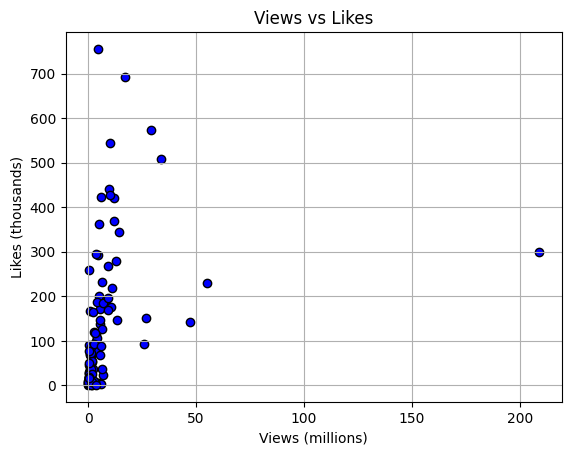

In [17]:
plt.scatter(df['Views_in_millions'], df['Likes_in_thousands'],
            color='blue', edgecolor='black')
plt.xlabel("Views (millions)")
plt.ylabel("Likes (thousands)")
plt.title("Views vs Likes")
plt.grid(True)
plt.show()

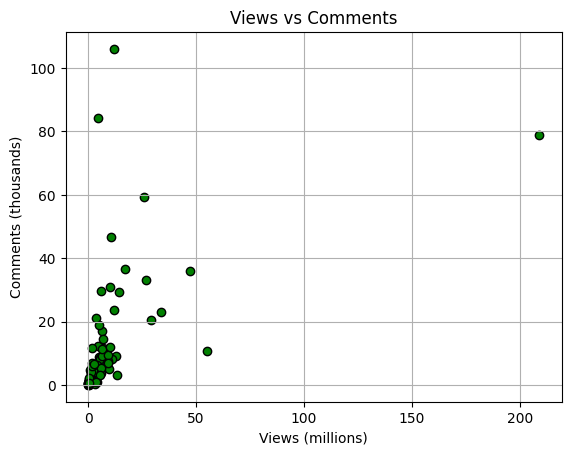

In [18]:
plt.scatter(df['Views_in_millions'], df['Comment_in_thousands'],
            color='green', edgecolor='black')
plt.xlabel("Views (millions)")
plt.ylabel("Comments (thousands)")
plt.title("Views vs Comments")
plt.grid(True)
plt.show()

In [19]:
# Average comments per category
avg_comments_category = df.groupby('Category')['Comment_in_thousands'].mean()
print(avg_comments_category)

Category
Education         5.933900
Entertainment    17.230760
Gaming            6.588000
Lifestyle        11.989034
Techonology       4.069375
Name: Comment_in_thousands, dtype: float64


In [20]:
# Calculate engagement rate
df['Engagement_Rate'] = (df['Likes_in_thousands'] + df['Comment_in_thousands']) / df['Views_in_millions']

# Get highest engagement video
top_engagement = df.loc[df['Engagement_Rate'].idxmax()]

print("Highest Engagement Video:")
print(top_engagement['Video_title'])
print("Engagement Rate:", top_engagement['Engagement_Rate'])

Highest Engagement Video:
W.i.S.H ft. Panther - Bolo Bolo | Official Music Video
Engagement Rate: 1296.25


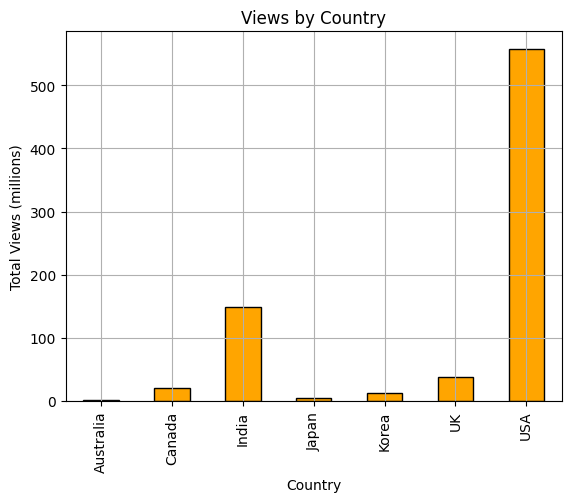

In [21]:
views_country = df.groupby('Country')['Views_in_millions'].sum()

views_country.plot(kind='bar', color='orange', edgecolor='black')
plt.xlabel("Country")
plt.ylabel("Total Views (millions)")
plt.title("Views by Country")
plt.grid(True)
plt.show()

In [22]:
top3_each_category = df.sort_values('Views_in_millions', ascending=False) \
                       .groupby('Category') \
                       .head(3)

print(top3_each_category[['Category', 'Video_title', 'Views_in_millions']])

         Category                                        Video_title  \
34  Entertainment            Surviving 24 Hours On A Deserted Island   
27  Entertainment           I went to Japan and Spent too much Money   
66  Entertainment                      Desis Try To Be Rich In Dubai   
31      Lifestyle                                       I got a cat.   
32      Lifestyle                              My Birds Laid Eggs...   
75      Education  HTML Tutorial For Beginners In Hindi (With Notes)   
9     Techonology         World's Cheapest vs Most Expensive Laptop!   
35      Lifestyle                     I Did not Eat Food For 30 Days   
47         Gaming  All Animatronics in Five Nights at Freddy's: S...   
71      Education  Dark Reality of Indian Education System | Dhru...   
58      Education  How to Make Learning as Addictive as Social Me...   
48         Gaming  The Story & Endings of Five Nights at Freddy's...   
42    Techonology             This guy has a PROBLEM - Tech Hoar

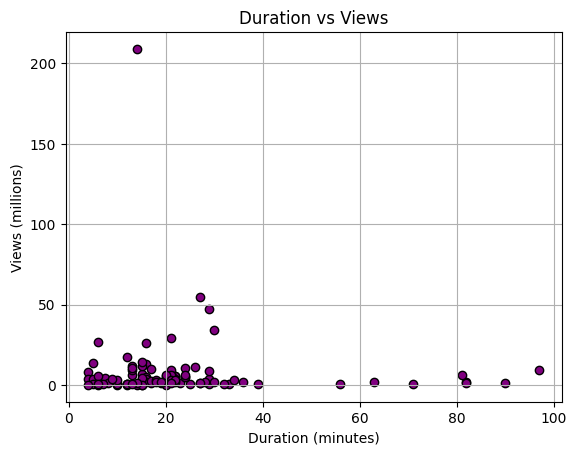

Correlation between Duration and Views: -0.047071325397351496


In [23]:
plt.scatter(df['Duration_in_minutes'], df['Views_in_millions'],
            color='purple', edgecolor='black')
plt.xlabel("Duration (minutes)")
plt.ylabel("Views (millions)")
plt.title("Duration vs Views")
plt.grid(True)
plt.show()

# Correlation value
correlation = df['Duration_in_minutes'].corr(df['Views_in_millions'])
print("Correlation between Duration and Views:", correlation)

In [24]:
# Total views per channel
views_channel = df.groupby('Channel_name')['Views_in_millions'].sum()
print(views_channel)

Channel_name
 JaidenAnimations               9.600
 Mrwhosetheboss                 5.500
 Venom's Tech                   1.330
 Zip Tie Tuning                 2.080
 bizlychannel                   0.640
Addie Bowley                   14.952
Aleena Rais Live                4.660
Alex Lee                        5.710
Alpharad                       55.000
Anurag Salgaonkar               1.000
Austin Evans                    1.100
Bohomeann                       6.660
CodeWithHarry                  15.140
Deep Pocket Monster             0.780
Dhruv Rathee                   10.300
Ed Sheeran                      8.200
Edmund Yong                     1.400
Emirichu                        7.010
ErikTheElectric                 6.240
Farah Khan                      3.000
FilterCopy                      0.580
HYBE LABELS                     3.800
Hailey _Your Korean Friend      2.900
Haley Pham                      3.545
JaidenAnimations               46.850
JeremyZuckerVEVO               26.800

In [ ]:
# Average likes per owner
avg_likes_owner = df.groupby('Owner_name')['Likes_in_thousands'].mean()
print(avg_likes_owner)

Owner_name
Abhyudaya and Gautami     159.000000
Abhyudaya and Gautami     269.000000
Addie Bowley               35.913333
Alakh Pandey              165.000000
Aleena Rais                 4.899000
Alex                       17.678500
Alex Lee                   41.516000
Ann Sara Luvies            53.003000
Anurag Salgaonkar          70.000000
Arun Rupesh Maini         156.866000
Austin Evans               69.000000
Dhruv Rathee              545.000000
Ed Sheeran                191.000000
Edmund Yong                66.500000
Emily Sim                  23.190000
Erik                       37.870000
Farah Khan                118.000000
FilterCopy                 15.688000
HYBE LABELS               100.000000
Hailey                     91.000000
Hailey                     30.000000
Haley Pham                 31.672500
Harry                     129.000000
Ina                         6.000000
Jacob Rabon IV            229.000000
Jaiden                    346.544000
Jeremy Zucker             1

In [25]:
# Engagement rate per video
df['Engagement_Rate'] = (df['Likes_in_thousands'] + df['Comment_in_thousands']) / df['Views_in_millions']

# Average engagement per owner
owner_engagement = df.groupby('Owner_name')['Engagement_Rate'].mean()

top_owner = owner_engagement.idxmax()

print("Owner with Highest Engagement Rate:", top_owner)
print("Engagement Rate:", owner_engagement.max())

Owner with Highest Engagement Rate: W.i.S.H.
Engagement Rate: 1296.25


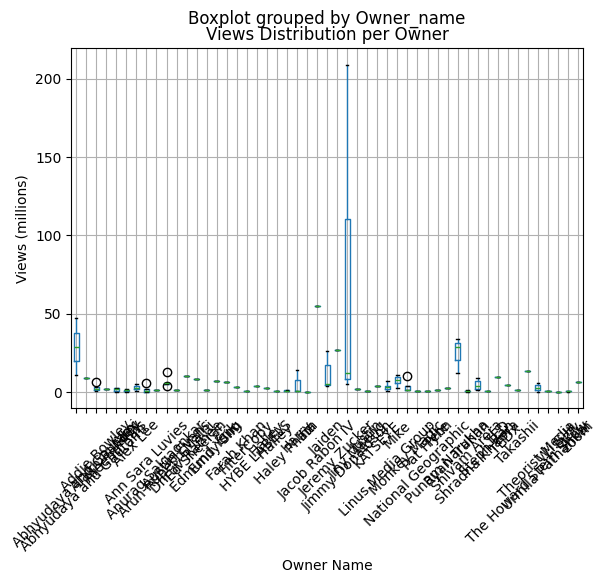

In [26]:
df.boxplot(column='Views_in_millions', by='Owner_name', grid=True)
plt.title("Views Distribution per Owner")
plt.xlabel("Owner Name")
plt.ylabel("Views (millions)")
plt.xticks(rotation=45)
plt.show()

In [27]:
# Average duration per channel
avg_duration_channel = df.groupby('Channel_name')['Duration_in_minutes'].mean()
print(avg_duration_channel)

Channel_name
 JaidenAnimations             11.700000
 Mrwhosetheboss               22.000000
 Venom's Tech                 13.500000
 Zip Tie Tuning               17.000000
 bizlychannel                 33.000000
Addie Bowley                  23.166667
Aleena Rais Live              30.000000
Alex Lee                      15.500000
Alpharad                      27.000000
Anurag Salgaonkar             27.000000
Austin Evans                  19.000000
Bohomeann                     25.500000
CodeWithHarry                 13.000000
Deep Pocket Monster           56.000000
Dhruv Rathee                  24.000000
Ed Sheeran                     4.000000
Edmund Yong                    7.000000
Emirichu                      15.000000
ErikTheElectric               21.000000
Farah Khan                    21.000000
FilterCopy                     6.000000
HYBE LABELS                    4.000000
Hailey _Your Korean Friend    18.500000
Haley Pham                    19.500000
JaidenAnimations           

In [28]:
# Extract year
df['Year'] = pd.to_datetime(df['Upload_date']).dt.year

uploads_owner_year = df.groupby(['Owner_name', 'Year']).size()
print(uploads_owner_year)

Owner_name              Year  
Abhyudaya and Gautami   2021.0    2
Abhyudaya and Gautami   2025.0    1
Addie Bowley            2025.0    6
Alakh Pandey            2025.0    1
Aleena Rais             2025.0    3
                                 ..
Urmila Pathankar        2025.0    1
W.i.S.H.                2025.0    1
bizly                   2023.0    1
                        2024.0    1
zoom                    2022.0    1
Length: 77, dtype: int64


In [29]:
# Choose one channel (example: first channel)
channel_name = df['Channel_name'].iloc[0]

channel_data = df[df['Channel_name'] == channel_name].copy()

# Drop rows with NaT in 'Upload_date' for the specific channel data
channel_data = channel_data.dropna(subset=['Upload_date'])

# Convert 'Upload_date' to ordinal for the cleaned channel_data
channel_data['Upload_numeric'] = channel_data['Upload_date'].apply(lambda x: x.toordinal())

correlation = channel_data['Upload_numeric'].corr(channel_data['Views_in_millions'])

print("Channel:", channel_name)
print("Correlation between Upload Date and Views:", correlation)

Channel: Addie Bowley
Correlation between Upload Date and Views: 0.3801185709862578


In [30]:
# Create ratio
df['Like_Dislike_Ratio'] = df['Likes_in_thousands'] / df['Dislikes_in_thousands']

ratio_owner = df.groupby('Owner_name')['Like_Dislike_Ratio'].mean()
print(ratio_owner)

Owner_name
Abhyudaya and Gautami        7.327141
Abhyudaya and Gautami       79.117647
Addie Bowley               299.644392
Alakh Pandey                82.500000
Aleena Rais                113.878918
Alex                       156.230530
Alex Lee                    66.516974
Ann Sara Luvies           1197.007548
Anurag Salgaonkar          205.882353
Arun Rupesh Maini           57.067168
Austin Evans                76.666667
Dhruv Rathee               136.250000
Ed Sheeran                 191.000000
Edmund Yong                 67.857143
Emily Sim                   23.519270
Erik                         5.333803
Farah Khan                  16.857143
FilterCopy                 118.848485
HYBE LABELS                 33.333333
Hailey                     194.029851
Hailey                     150.000000
Haley Pham                 111.142998
Harry                       70.216452
Ina                        139.534884
Jacob Rabon IV             176.153846
Jaiden                     219.348790
J

In [31]:
# Average duration per owner
avg_duration_owner = df.groupby('Owner_name')['Duration_in_minutes'].mean()
print(avg_duration_owner)

Owner_name
Abhyudaya and Gautami     21.000000
Abhyudaya and Gautami     29.000000
Addie Bowley              23.166667
Alakh Pandey              82.000000
Aleena Rais               30.000000
Alex                      17.000000
Alex Lee                  15.500000
Ann Sara Luvies           25.500000
Anurag Salgaonkar         27.000000
Arun Rupesh Maini         18.833333
Austin Evans              19.000000
Dhruv Rathee              24.000000
Ed Sheeran                 4.000000
Edmund Yong                7.000000
Emily Sim                 15.000000
Erik                      21.000000
Farah Khan                21.000000
FilterCopy                 6.000000
HYBE LABELS                4.000000
Hailey                     5.000000
Hailey                    32.000000
Haley Pham                19.500000
Harry                     13.000000
Ina                       12.000000
Jacob Rabon IV            27.000000
Jaiden                    13.480000
Jeremy Zucker              6.000000
Jimmy Donaldson  

In [33]:
# Average views per category
avg_views_category = df.groupby('Category')['Views_in_millions'].mean()

# Highest category
top_category = avg_views_category.idxmax()

print("Category with Highest Average Views:", top_category)
print("Average Views:", avg_views_category.max())

Category with Highest Average Views: Entertainment
Average Views: 19.43728


In [34]:
# Average metrics per language
language_metrics = df.groupby('Video_language')[[
    'Views_in_millions',
    'Likes_in_thousands',
    'Comment_in_thousands'
]].mean()

print(language_metrics)

                Views_in_millions  Likes_in_thousands  Comment_in_thousands
Video_language                                                             
English                  8.429571          138.544338             10.555234
Hindi                    5.890000          129.951652              9.363739


In [35]:
# Convert date
df['Upload_date'] = pd.to_datetime(df['Upload_date'])

# Convert to numeric
df['Upload_numeric'] = df['Upload_date'].astype('int64')

# Ensure views numeric
df['Views_in_millions'] = pd.to_numeric(df['Views_in_millions'], errors='coerce')

# Correlation
correlation = df['Upload_numeric'].corr(df['Views_in_millions'])

print("Correlation between Upload Date and Views:", correlation)

Correlation between Upload Date and Views: 0.013964340785402407


In [36]:
# Extract day name
df['Day'] = df['Upload_date'].dt.day_name()

# Create weekend column
df['Is_Weekend'] = df['Day'].isin(['Saturday', 'Sunday'])

# Average engagement for weekend vs weekday
weekend_engagement = df.groupby('Is_Weekend')[[
    'Likes_in_thousands',
    'Comment_in_thousands'
]].mean()

print(weekend_engagement)

            Likes_in_thousands  Comment_in_thousands
Is_Weekend                                          
False               115.995147              8.263956
True                180.285375             14.567813


In [37]:
print("1. Highest Average View Category:", top_category)
print("2. Total Unique Channels:", df['Channel_name'].nunique())
print("3. Total Unique Owners:", df['Owner_name'].nunique())
print("4. Overall Average Views:", df['Views_in_millions'].mean())
print("5. Overall Correlation (Date vs Views):", correlation)

1. Highest Average View Category: Entertainment
2. Total Unique Channels: 53
3. Total Unique Owners: 51
4. Overall Average Views: 7.845470000000001
5. Overall Correlation (Date vs Views): 0.013964340785402407
